In [1]:
import glob
import os

import anndata as ad
import scipy as sc
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt

In [11]:
# INPUT_DIR = "/n/groups/kirschner/Will/BedRest"
INPUT_DIR = "/Users/willtrim/Documents/projs/bedrest/outputs/"

tpm_fp = os.path.join(INPUT_DIR, "rsem.merged.gene_tpm.tsv")

phenotypes_fp = os.path.join(INPUT_DIR, "BedRest_blood_phenotype.csv")

In [13]:
tpm = pd.read_csv(tpm_fp, sep="\t")
tpm = tpm.drop("transcript_id(s)", axis=1).set_index("gene_id")
tpm.head()

,SRR15503376_GSM5526409_A1_POST_Homo_sapiens_RNA-Seq,SRR15503377_GSM5526410_A2_POST_Homo_sapiens_RNA-Seq,SRR15503378_GSM5526411_B1_POST_Homo_sapiens_RNA-Seq,SRR15503379_GSM5526412_B2_POST_Homo_sapiens_RNA-Seq,SRR15503380_GSM5526413_C1_POST_Homo_sapiens_RNA-Seq,SRR15503381_GSM5526414_C2_POST_Homo_sapiens_RNA-Seq,SRR15503382_GSM5526415_D1_POST_Homo_sapiens_RNA-Seq,SRR15503383_GSM5526416_D2_POST_Homo_sapiens_RNA-Seq,SRR15503384_GSM5526417_E1_POST_Homo_sapiens_RNA-Seq,SRR15503385_GSM5526418_E2_POST_Homo_sapiens_RNA-Seq,...,SRR15503406_GSM5526439_F1_PRE_Homo_sapiens_RNA-Seq,SRR15503407_GSM5526440_F2_PRE_Homo_sapiens_RNA-Seq,SRR15503408_GSM5526441_G1_PRE_Homo_sapiens_RNA-Seq,SRR15503409_GSM5526442_G2_PRE_Homo_sapiens_RNA-Seq,SRR15503410_GSM5526443_H1_PRE_Homo_sapiens_RNA-Seq,SRR15503411_GSM5526444_H2_PRE_Homo_sapiens_RNA-Seq,SRR15503412_GSM5526445_I1_PRE_Homo_sapiens_RNA-Seq,SRR15503413_GSM5526446_I2_PRE_Homo_sapiens_RNA-Seq,SRR15503414_GSM5526447_J1_PRE_Homo_sapiens_RNA-Seq,SRR15503415_GSM5526448_J2_PRE_Homo_sapiens_RNA-Seq
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.16,23.12,25.38,16.35,22.63,24.90,20.33,23.86,20.79,18.26,23.64,...,28.68,22.26,23.74,20.39,21.64,24.37,21.94,17.92,19.73,26.51
ENSG00000000005.6,23.46,61.87,20.27,34.22,35.02,47.29,34.72,23.35,47.23,55.45,...,51.00,42.34,51.40,24.97,30.38,33.19,135.26,32.71,33.11,28.57
ENSG00000000419.14,41.56,40.17,49.03,45.49,48.48,38.92,42.05,42.57,36.13,38.40,...,40.04,41.44,44.04,41.25,49.10,40.79,38.96,38.57,34.80,45.30
ENSG00000000457.14,5.39,5.12,6.33,4.46,6.56,4.52,5.61,5.35,5.35,4.86,...,5.44,5.23,6.06,5.60,4.63,5.14,5.72,4.81,4.55,6.10
ENSG00000000460.17,2.55,2.23,2.22,1.38,1.60,2.01,1.92,2.14,1.77,2.02,...,2.02,1.59,2.01,1.75,1.61,1.62,2.65,1.33,2.06,2.37


In [17]:
sample_names = pd.DataFrame(tpm.columns.to_series())
sample_names[["patient", "tmp"]] = sample_names[0].str.split("_", expand=True).iloc[:,[2,3]]
sample_names.loc[sample_names.tmp == "POST", "tmp"] = "Post"
sample_names.loc[sample_names.tmp == "PRE", "tmp"] = "Pre"
cols = ["patient", "tmp"]
sample_names["sample_name"] = sample_names.tmp + "_" + sample_names.patient
sample_names.head()

,0,patient,tmp,sample_name
SRR15503376_GSM5526409_A1_POST_Homo_sapiens_RNA-Seq,SRR15503376_GSM5526409_A1_POST_Homo_sapiens_RN...,A1,Post,Post_A1
SRR15503377_GSM5526410_A2_POST_Homo_sapiens_RNA-Seq,SRR15503377_GSM5526410_A2_POST_Homo_sapiens_RN...,A2,Post,Post_A2
SRR15503378_GSM5526411_B1_POST_Homo_sapiens_RNA-Seq,SRR15503378_GSM5526411_B1_POST_Homo_sapiens_RN...,B1,Post,Post_B1
SRR15503379_GSM5526412_B2_POST_Homo_sapiens_RNA-Seq,SRR15503379_GSM5526412_B2_POST_Homo_sapiens_RN...,B2,Post,Post_B2
SRR15503380_GSM5526413_C1_POST_Homo_sapiens_RNA-Seq,SRR15503380_GSM5526413_C1_POST_Homo_sapiens_RN...,C1,Post,Post_C1


In [18]:
tpm.columns = sample_names.loc[tpm.columns, "sample_name"]
tpm.head()

sample_name,Post_A1,Post_A2,Post_B1,Post_B2,Post_C1,Post_C2,Post_D1,Post_D2,Post_E1,Post_E2,...,Pre_F1,Pre_F2,Pre_G1,Pre_G2,Pre_H1,Pre_H2,Pre_I1,Pre_I2,Pre_J1,Pre_J2
gene_id,,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.16,23.12,25.38,16.35,22.63,24.90,20.33,23.86,20.79,18.26,23.64,...,28.68,22.26,23.74,20.39,21.64,24.37,21.94,17.92,19.73,26.51
ENSG00000000005.6,23.46,61.87,20.27,34.22,35.02,47.29,34.72,23.35,47.23,55.45,...,51.00,42.34,51.40,24.97,30.38,33.19,135.26,32.71,33.11,28.57
ENSG00000000419.14,41.56,40.17,49.03,45.49,48.48,38.92,42.05,42.57,36.13,38.40,...,40.04,41.44,44.04,41.25,49.10,40.79,38.96,38.57,34.80,45.30
ENSG00000000457.14,5.39,5.12,6.33,4.46,6.56,4.52,5.61,5.35,5.35,4.86,...,5.44,5.23,6.06,5.60,4.63,5.14,5.72,4.81,4.55,6.10
ENSG00000000460.17,2.55,2.23,2.22,1.38,1.60,2.01,1.92,2.14,1.77,2.02,...,2.02,1.59,2.01,1.75,1.61,1.62,2.65,1.33,2.06,2.37


In [10]:
phenotypes = pd.read_csv(phenotypes_fp)
phenotypes.head()

,Participant ID,Group,Time Point,Venous Glucose (mmol/L),Venous Insulin (mU/L),Art. Glucose (mmol/L),Fat ox/kg,cho ox/Kg,FFA (mmol/L),TAG (mmol/L),Art. Insulin (mIU/L),Glucose Disposal
0,A1,Cocktail,Pre Bed Rest,4.8840,2.8600,4.30,1.887698,0.318964,0.415,0.58,4.70,8.520406
1,B1,Cocktail,Pre Bed Rest,4.8285,3.2250,4.16,1.321354,1.248777,0.390,0.46,5.90,6.175030
2,C1,Control,Pre Bed Rest,4.8840,7.1990,4.26,1.787597,0.315102,0.554,0.51,12.62,6.301969
3,D1,Control,Pre Bed Rest,4.9950,4.5270,4.63,1.950858,NaN,0.949,0.40,12.57,4.914221
4,E1,Control,Pre Bed Rest,4.6620,3.6575,4.45,1.391448,0.888337,0.427,1.24,19.94,5.444510


# Deltas

In [31]:
tmp_col = "Time Point"
id_col = "Participant ID"

phenotypes_post = phenotypes.loc[phenotypes[tmp_col] == "Post Bed Rest",:].set_index(id_col).drop(["Group", tmp_col], axis=1)
phenotypes_pre = phenotypes.loc[phenotypes[tmp_col] == "Pre Bed Rest",:].set_index(id_col).drop(["Group", tmp_col], axis=1)

phenotypes_d = np.log2(phenotypes_post / phenotypes_pre).T
phenotypes_d.head()

Participant ID,A1,B1,C1,D1,E1,F1,G1,H1,I1,J1,A2,B2,C2,D2,E2,F2,G2,H2,I2,J2
Venous Glucose (mmol/L),-0.174029,-0.273018,-0.067114,-0.082462,0.115477,-0.211504,-0.376854,-0.172181,-0.032790,-0.086415,-0.109624,-0.284453,-0.095578,-0.073063,-0.035189,-0.056584,-0.087463,-0.088537,-0.053111,-0.103093
Venous Insulin (mU/L),0.000000,0.231756,0.220014,0.566790,0.917828,0.492699,-0.045425,-0.430004,1.263455,0.252640,0.117905,-0.010051,0.535332,0.345331,0.229956,0.401615,0.458582,1.659190,1.744076,0.000000
Art. Glucose (mmol/L),-0.079308,-0.052981,0.023514,0.084711,-0.029477,0.072544,-0.075345,-0.098597,0.114486,-0.140481,0.029278,-0.064130,-0.021113,0.006757,0.061401,0.000000,0.290779,-0.021321,0.091423,0.000000
Fat ox/kg,-0.551219,0.235229,-0.116439,-0.346424,-0.033928,0.229640,-0.227897,-0.898261,0.091135,-0.887003,0.838115,0.460269,-0.108674,0.296520,-0.418756,-0.190629,0.678881,-0.150799,0.584552,0.330520
cho ox/Kg,1.778601,-0.124661,0.703378,NaN,0.165745,NaN,0.096893,0.732725,-0.509932,0.423614,-1.803555,0.319634,0.441616,-0.238576,NaN,0.080822,-1.627056,NaN,-0.665191,-1.236900


In [60]:
tpm_pre = tpm.loc[:,tpm.columns.to_series().str.startswith("Pre")]
tpm_post = tpm.loc[:,tpm.columns.to_series().str.startswith("Post")]

tpm_pre.columns = tpm_pre.columns.to_series().str.replace("Pre_", "")
tpm_post.columns = tpm_post.columns.to_series().str.replace("Post_", "")

In [61]:
threshold = 1
min_sample = 3

assert (tpm_pre.index == tpm_post.index).all()

idx = ((tpm_pre >= threshold).sum(axis=1) >= min_sample) | ((tpm_post >= threshold).sum(axis=1) >= min_sample)
tpm_pre = tpm_pre.loc[idx,:]
tpm_post = tpm_post.loc[idx,:]

In [62]:
tpm_d = np.log2(tpm_post / tpm_pre)

/opt/miniconda3/envs/rnaseq/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: divide by zero encountered in log2
  result = func(self.values, **kwargs)


In [63]:
tpm_d.head()

sample_name,A1,A2,B1,B2,C1,C2,D1,D2,E1,E2,F1,F2,G1,G2,H1,H2,I1,I2,J1,J2
gene_id,,,,,,,,,,,,,,,,,,,,
ENSG00000000003.16,0.217824,-0.033154,-0.223526,-0.044568,0.016315,-0.209051,-0.105489,-0.122984,-0.419967,0.053462,-0.538192,0.028874,-0.035062,0.115532,-0.275354,0.111601,-0.050180,-0.081989,-0.012485,-0.158609
ENSG00000000005.6,-0.494447,0.153636,-0.197885,-0.217204,0.354530,0.229682,-0.311921,-0.522030,-1.123047,-0.157353,-0.549339,0.137999,-0.094532,-0.053559,-0.749525,-0.834671,-0.393371,-0.221731,-0.439795,-0.215843
ENSG00000000419.14,0.088027,-0.230833,0.092972,0.108990,0.173724,-0.112623,0.356212,0.011569,-0.159729,-0.130313,-0.184228,-0.056806,-0.018463,0.019109,-0.301143,0.176864,0.074685,-0.308710,-0.039505,-0.023438
ENSG00000000457.14,0.213055,-0.076816,0.009145,-0.439891,0.175158,-0.476737,-0.155855,0.109199,0.352589,0.048296,-0.359542,-0.242765,0.037597,-0.258918,0.240529,0.215963,-0.214428,-0.394193,0.121562,-0.183887
ENSG00000000460.17,1.028569,0.208443,0.326810,-0.672835,-0.892391,-0.308950,0.425091,0.532014,0.136689,0.058299,0.659201,0.301827,-0.051139,-0.291340,-0.191366,0.230006,-0.550003,-0.124545,-0.767637,-0.303781


In [59]:
tpm_d.shape

(18266, 20)

# Correlataions

In [64]:
def correlate_genes_with_pheno(gene_expr, pheno_vals):
    
    cor_res = []
    
    for i, gene in gene_expr.iterrows():
    
        if (~(pd.isna(gene) | np.isinf(gene))).sum() >= 6:
        
            for j, pheno in pheno_vals.iterrows():
                try:
                    gene_cor_res = sc.stats.spearmanr(gene, pheno, nan_policy="omit")
                except Exception:
                    return gene, pheno
                cor_res.append({"gene": i, "pheno": j, "r": gene_cor_res.statistic, "pvalue": gene_cor_res.pvalue})
    print("Done!")
    return cor_res

In [65]:
remove_samples = ["I2", ]
tpm_d = tpm_d.loc[:,~tpm_d.columns.isin(remove_samples)]
tpm_d.head()

sample_name,A1,A2,B1,B2,C1,C2,D1,D2,E1,E2,F1,F2,G1,G2,H1,H2,I1,J1,J2
gene_id,,,,,,,,,,,,,,,,,,,
ENSG00000000003.16,0.217824,-0.033154,-0.223526,-0.044568,0.016315,-0.209051,-0.105489,-0.122984,-0.419967,0.053462,-0.538192,0.028874,-0.035062,0.115532,-0.275354,0.111601,-0.050180,-0.012485,-0.158609
ENSG00000000005.6,-0.494447,0.153636,-0.197885,-0.217204,0.354530,0.229682,-0.311921,-0.522030,-1.123047,-0.157353,-0.549339,0.137999,-0.094532,-0.053559,-0.749525,-0.834671,-0.393371,-0.439795,-0.215843
ENSG00000000419.14,0.088027,-0.230833,0.092972,0.108990,0.173724,-0.112623,0.356212,0.011569,-0.159729,-0.130313,-0.184228,-0.056806,-0.018463,0.019109,-0.301143,0.176864,0.074685,-0.039505,-0.023438
ENSG00000000457.14,0.213055,-0.076816,0.009145,-0.439891,0.175158,-0.476737,-0.155855,0.109199,0.352589,0.048296,-0.359542,-0.242765,0.037597,-0.258918,0.240529,0.215963,-0.214428,0.121562,-0.183887
ENSG00000000460.17,1.028569,0.208443,0.326810,-0.672835,-0.892391,-0.308950,0.425091,0.532014,0.136689,0.058299,0.659201,0.301827,-0.051139,-0.291340,-0.191366,0.230006,-0.550003,-0.767637,-0.303781


In [66]:
phenotypes_d = phenotypes_d.loc[:,tpm_d.columns]

In [67]:
d_cors = correlate_genes_with_pheno(tpm_d, phenotypes_d)

Done!


In [75]:
d_cors_df = pd.DataFrame(d_cors)
d_cors_df.head()

,gene,pheno,r,pvalue
0,ENSG00000000003.16,Venous Glucose (mmol/L),0.149123,0.542322
1,ENSG00000000003.16,Venous Insulin (mU/L),-0.072839,0.766973
2,ENSG00000000003.16,Art. Glucose (mmol/L),0.069329,0.777928
3,ENSG00000000003.16,Fat ox/kg,-0.184211,0.450285
4,ENSG00000000003.16,cho ox/Kg,-0.003571,0.989921


In [76]:
d_cors_df["sign"] = 1
d_cors_df.loc[d_cors_df.r < 0, "sign"] = -1
d_cors_df["pvalue * sign(r)"] = d_cors_df["pvalue"] * d_cors_df["sign"]
d_cors_df.head()

,gene,pheno,r,pvalue,sign,pvalue * sign(r)
0,ENSG00000000003.16,Venous Glucose (mmol/L),0.149123,0.542322,1,0.542322
1,ENSG00000000003.16,Venous Insulin (mU/L),-0.072839,0.766973,-1,-0.766973
2,ENSG00000000003.16,Art. Glucose (mmol/L),0.069329,0.777928,1,0.777928
3,ENSG00000000003.16,Fat ox/kg,-0.184211,0.450285,-1,-0.450285
4,ENSG00000000003.16,cho ox/Kg,-0.003571,0.989921,-1,-0.989921


In [77]:
pheno_order = ['Art. Insulin (mIU/L)', 'Venous Insulin (mU/L)', 'Glucose Disposal ',
       'Art. Glucose (mmol/L)', 'Venous Glucose (mmol/L)', 'cho ox/Kg',
       'TAG (mmol/L)', 'FFA (mmol/L)', 'Fat ox/kg']
d_cors_df.pheno = pd.Categorical(d_cors_df.pheno, categories=pheno_order, ordered=True)

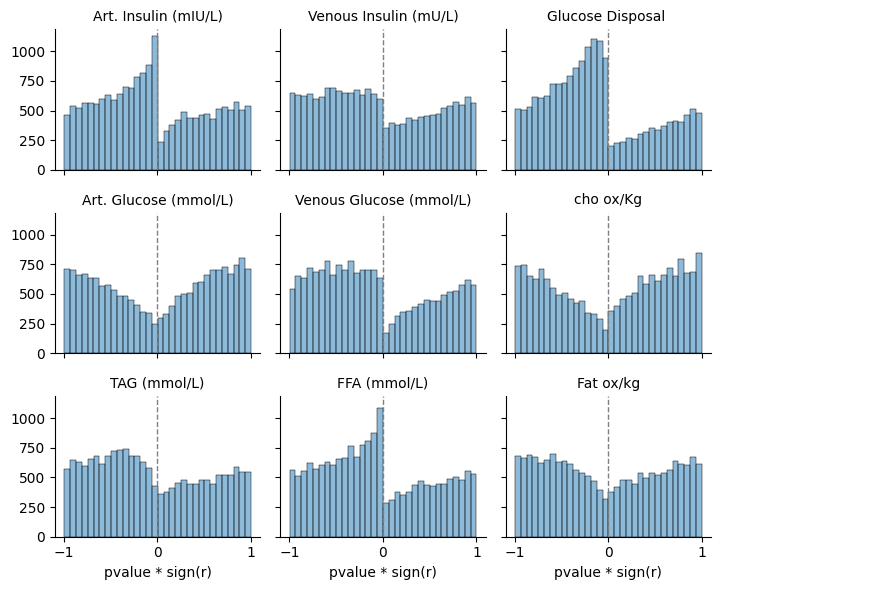

In [78]:
g = sns.FacetGrid(d_cors_df, col="pheno", col_wrap=3, height=2, aspect=1.2, )
g.map(sns.histplot, "pvalue * sign(r)", alpha=0.5, bins=32)#, hue="tmp")
g.refline(x=0, color="grey", linestyle="--", linewidth=1)
g.set_titles(col_template="{col_name}") #, row_template="{row_name}")
g.set_axis_labels("pvalue * sign(r)", "")
g.add_legend(bbox_to_anchor=(1.2, 0.1))
# g.set_titles(col_template="{col_name}")

plt.tight_layout()

In [79]:
d_cors_df_grouped = d_cors_df.groupby("pheno")

/var/folders/w5/5q2ysxtd5vv9bc1cf7bhf07w0000gn/T/ipykernel_30745/3148535969.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  d_cors_df_grouped = d_cors_df.groupby("pheno")


In [73]:
pheno_names = {
    'Venous Glucose (mmol/L)': "glucose_ven",
    'Venous Insulin (mU/L)': "insulin_ven",
    'Art. Glucose (mmol/L)': "glucose_art",
    'Fat ox/kg': "fat_ox",
    'cho ox/Kg': "cho_ox",
    'FFA (mmol/L)': "FFA",
    'TAG (mmol/L)': "TAG",
    'Art. Insulin (mIU/L)': "insulin_art",
    'Glucose Disposal ': "glucose_disposal",
    "insulin_AV": "insulin_AV",
    "glucose_AV": "glucose_AV",
}

In [74]:
cor_dir = os.path.join(INPUT_DIR, "delta_cors")
if not os.path.exists(cor_dir):
    os.makedirs(cor_dir)

In [81]:
for pheno, pheno_cor in d_cors_df_grouped:
    pheno_name = pheno_names[pheno]
    pheno_cor.to_csv(os.path.join(cor_dir, f"{pheno_name}.csv"), index=False, )

In [85]:
d_cors_df_grouped.get_group("Glucose Disposal ").sort_values("pvalue").head()

,gene,pheno,r,pvalue,sign,pvalue * sign(r)
123974,ENSG00000235098.9,Glucose Disposal,-0.784211,0.000071,-1,-0.000071
75248,ENSG00000163138.19,Glucose Disposal,-0.750877,0.000212,-1,-0.000212
27962,ENSG00000111206.13,Glucose Disposal,-0.714035,0.000595,-1,-0.000595
32696,ENSG00000115970.19,Glucose Disposal,-0.712281,0.000623,-1,-0.000623
94337,ENSG00000177133.15,Glucose Disposal,0.710526,0.000651,1,0.000651


In [86]:
d_cors_df_grouped.get_group("Art. Insulin (mIU/L)").sort_values("pvalue").head()

,gene,pheno,r,pvalue,sign,pvalue * sign(r)
143881,ENSG00000274427.1,Art. Insulin (mIU/L),1.000000,0.000000e+00,1,0.000000e+00
61774,ENSG00000146243.14,Art. Insulin (mIU/L),-0.933333,5.543729e-09,-1,-5.543729e-09
115765,ENSG00000213853.10,Art. Insulin (mIU/L),-0.840351,6.688950e-06,-1,-6.688950e-06
133504,ENSG00000257704.4,Art. Insulin (mIU/L),-0.824561,1.408633e-05,-1,-1.408633e-05
52657,ENSG00000137312.15,Art. Insulin (mIU/L),-0.815789,2.065885e-05,-1,-2.065885e-05


# fgsea results dotplotting

In [98]:
fgsea_dir = os.path.join(cor_dir, "fgsea_res")

## KEGG

In [115]:
db = "KEGG"

In [116]:
# fgsea_fps_pos = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "pos", f"*.{db}.csv"))}
# fgsea_fps_neg = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(INPUT_DIR, "neg", f"*.{db}.csv"))}
fgsea_fps = {os.path.basename(fgsea_fp).rsplit(".", maxsplit=1)[0]: fgsea_fp for fgsea_fp in glob.glob(os.path.join(fgsea_dir, f"*.{db}.csv"))}


pval_threshold = 1e-2


pvals = {}
NES = {}
LE = {}

for pheno_db, fgsea_fp in fgsea_fps.items():

    # fgsea_fp_neg = fgsea_fps_neg[pheno_db]
    # pheno, db = pheno_db.split(".")
    
    # fgsea_res_pos = pd.read_csv(fgsea_fp_pos).set_index("pathway")
    # fgsea_res_neg = pd.read_csv(fgsea_fp_neg).set_index("pathway")

    # fgsea_res_pos = fgsea_res_pos.loc[fgsea_res_pos.padj < pval_threshold,:]
    # fgsea_res_neg = fgsea_res_neg.loc[fgsea_res_neg.padj < pval_threshold,:]

    # fgsea_res = pd.concat([fgsea_res_pos, fgsea_res_neg], axis=0)

    pheno, db = pheno_db.split(".")
    
    fgsea_res = pd.read_csv(fgsea_fp).set_index("pathway")
    
    # fgsea_res = fgsea_res.loc[fgsea_res.padj < pval_threshold,:]
    # fgsea_res_neg = fgsea_res_neg.loc[fgsea_res_neg.padj < pval_threshold,:]

    # fgsea_res = pd.concat([fgsea_res_pos, fgsea_res_neg], axis=0)

    assert len(fgsea_res.index.unique()) == fgsea_res.shape[0]

    LE_len = fgsea_res.leadingEdge.str.split("|", expand=False).apply(len)
    LE_percentage = LE_len / fgsea_res["size"]
    
    LE[pheno_db] = LE_percentage
    NES[pheno_db] = fgsea_res.NES
    
    pvals[pheno_db] = fgsea_res.padj

In [117]:
LE_df = pd.concat(LE.values(), axis=1)
LE_df.columns = LE.keys()
LE_df.head()

,glucose_art.KEGG,insulin_ven.KEGG,FFA.KEGG,fat_ox.KEGG,glucose_disposal.KEGG,TAG.KEGG,cho_ox.KEGG,glucose_ven.KEGG,insulin_art.KEGG
pathway,,,,,,,,,
2-Oxocarboxylic acid metabolism,0.740741,0.481481,0.703704,0.666667,0.148148,0.185185,0.629630,0.259259,0.518519
ABC transporters,0.235294,0.294118,0.205882,0.323529,0.352941,0.441176,0.264706,0.411765,0.147059
AGE-RAGE signaling pathway in diabetic complications,0.268817,0.161290,0.376344,0.290323,0.623656,0.344086,0.268817,0.354839,0.193548
AMPK signaling pathway,0.203704,0.138889,0.509259,0.296296,0.518519,0.564815,0.268519,0.342593,0.296296
ATP-dependent chromatin remodeling,0.247423,0.309278,0.432990,0.268041,0.484536,0.278351,0.206186,0.505155,0.319588


In [118]:
pvals_df = pd.concat(pvals.values(), axis=1)
pvals_df.columns = pvals.keys()
pvals_df.head()

,glucose_art.KEGG,insulin_ven.KEGG,FFA.KEGG,fat_ox.KEGG,glucose_disposal.KEGG,TAG.KEGG,cho_ox.KEGG,glucose_ven.KEGG,insulin_art.KEGG
pathway,,,,,,,,,
2-Oxocarboxylic acid metabolism,0.487898,0.911842,0.000183,0.095442,0.209469,0.998971,0.005288,0.658052,0.055633
ABC transporters,0.966150,0.580453,0.349175,0.618490,0.503801,0.219915,0.597018,0.860821,0.988725
AGE-RAGE signaling pathway in diabetic complications,0.999949,0.756962,0.061787,0.183330,0.087091,0.674763,0.743041,0.143969,0.571339
AMPK signaling pathway,0.957128,0.996415,0.000554,0.076194,0.408544,0.586785,0.360570,0.984214,0.896746
ATP-dependent chromatin remodeling,0.999949,0.860321,0.964430,0.244681,0.059960,0.991580,0.751092,0.360708,0.546997


In [128]:
NES_df = pd.concat(NES.values(), axis=1)
NES_df.columns = NES.keys()
NES_df.head()

,glucose_art.KEGG,insulin_ven.KEGG,FFA.KEGG,fat_ox.KEGG,glucose_disposal.KEGG,TAG.KEGG,cho_ox.KEGG,glucose_ven.KEGG,insulin_art.KEGG
pathway,,,,,,,,,
2-Oxocarboxylic acid metabolism,-1.720209,-0.858452,-2.083545,-1.705107,-1.292776,-0.559386,2.113221,-1.118899,1.828691
ABC transporters,-1.017969,1.148336,-1.212444,-1.103793,-1.069622,-1.497800,1.179724,-0.926726,-0.613136
AGE-RAGE signaling pathway in diabetic complications,-0.861380,0.989189,-1.441137,-1.436173,-1.326480,-1.091655,1.057822,1.433005,-1.196652
AMPK signaling pathway,1.059322,0.861592,-1.788074,-1.541037,-1.096226,-1.136713,1.299942,-0.795317,0.947903
ATP-dependent chromatin remodeling,0.920446,-0.937520,-0.684882,1.341216,-1.360931,0.832062,-1.039316,-1.319432,-1.216996


In [130]:
NES_df.loc["Citrate cycle (TCA cycle)",]

glucose_art.KEGG        -1.608526
insulin_ven.KEGG        -0.757034
FFA.KEGG                -2.186754
fat_ox.KEGG             -1.688961
glucose_disposal.KEGG   -0.848949
TAG.KEGG                -0.806805
cho_ox.KEGG              2.065514
glucose_ven.KEGG        -1.008065
insulin_art.KEGG         1.171830
Name: Citrate cycle (TCA cycle), dtype: float64

In [120]:
pval_threshold = 5e-2

NES_df[pvals_df >= pval_threshold] = np.nan
NES_df = NES_df.loc[~NES_df.isna().all(axis=1),:]

In [121]:
adata = ad.AnnData(NES_df.values)

adata.var_names = NES_df.columns
adata.obs_names = NES_df.index

adata.obs["pathway"] = pd.Categorical(adata.obs_names)
adata.obs.index.rename("index", inplace=True)
# adata.obs

In [122]:
markers = []
ordered = ["glucose_ven", "glucose_art", "insulin_ven", "insulin_art", "glucose_disposal", "FFA", "TAG", "cho_ox", "fat_ox"]
for key in ordered:
    markers.append(f"{key}.{db}")

In [123]:
assert (LE_df.columns == adata.var_names).all()
LE_df = LE_df.loc[adata.obs_names,:]
LE_df[np.isnan(adata.X)] = 0
LE_df = LE_df[markers]

In [91]:
adata.obs["abs_max"] = np.nanmax(abs(adata.X), axis=1, )
adata = adata[adata.obs.sort_values("abs_max", ascending=False).index,:].copy()
adata.obs.pathway = pd.Categorical(adata.obs.pathway, ordered=True, categories=adata.obs.pathway)

In [124]:
LE_df = LE_df.loc[adata.obs_names,:].copy()

In [127]:
bs = 50
save_fig = True

assert (adata.obs_names == LE_df.index).all()

for i in range(0, adata.shape[0], bs):
    p = dotplot(
        adata[i:(i + bs),:],
        var_names=markers,
        groupby="pathway",
        expression_cutoff=-100,
        vmin=np.nanmin(adata.X),
        vmax=np.nanmax(adata.X),
        cmap="coolwarm",
        dot_size_df=LE_df.iloc[i:(i + bs),:],
        swap_axes=True,
        return_fig=True
    ) #, dendrogram=True)
    
    p.grid=True
    p.group_cmaps = None
    p.make_figure()

    
    if save_fig:
        plt.savefig(f'figures_deltas/KEGG_{i}.png', bbox_inches='tight')
        plt.close()

# Dotplot function

In [87]:
from scanpy._utils import _doc_params, _empty

In [88]:
from scanpy.plotting._anndata import _prepare_dataframe
from scanpy.plotting._baseplot_class import _var_groups

In [89]:
from scanpy.plotting import DotPlot
from scanpy._utils import _doc_params, _empty
from scanpy.plotting._utils import (
    _dk,
    check_colornorm,
    fix_kwds,
    make_grid_spec,
    savefig_or_show,
)
from matplotlib import colormaps, gridspec
from scanpy.plotting._anndata import (
    VarGroups,
    _plot_dendrogram,
    _plot_var_groups_brackets,
    _prepare_dataframe,
    _reorder_categories_after_dendrogram,
)


class DotPlot_(DotPlot):

    @staticmethod
    def _dotplot(  # noqa: PLR0912, PLR0913, PLR0915
        dot_size: pd.DataFrame,
        dot_color: pd.DataFrame,
        dot_ax,
        *,
        cmap,
        group_cmaps,
        color_on,
        dot_max: float | None,
        dot_min: float | None,
        standard_scale,
        smallest_dot: float,
        largest_dot: float,
        size_exponent: float,
        edge_color,
        edge_lw: float | None,
        grid: bool,
        x_padding: float,
        y_padding: float,
        vmin: float | None,
        vmax: float | None,
        vcenter: float | None,
        norm,
        are_axes_swapped: bool | None,
        **kwds,
    ):
        """Make a *dot plot* given two data frames.
    
        One containing the dot size and other containing the dot color.
        The indices and columns of the data frame are used to label the output image.
    
        The dots are plotted using :func:`matplotlib.pyplot.scatter`. Thus, additional
        arguments can be passed.
    
        Parameters
        ----------
        dot_size
            Data frame containing the dot_size.
        dot_color
            Data frame containing the dot_color, should have the same,
            shape, columns and indices as dot_size.
        dot_ax
            matplotlib axis
        cmap
        color_on
        dot_max
        dot_min
        standard_scale
        smallest_dot
        edge_color
        edge_lw
        grid
        x_padding
        y_padding
            See `style`
        kwds
            Are passed to :func:`matplotlib.pyplot.scatter`.
    
        Returns
        -------
        matplotlib.colors.Normalize, dot_min, dot_max
    
        """
        assert dot_size.shape == dot_color.shape, (
            f"please check that dot_size and dot_color dataframes have the same shape"
        )
        
        # assert list(dot_size.index) == list(dot_color.index), (
        #     f"please check that dot_size {list(dot_size.index)} and dot_color {list(dot_color.index)} dataframes have the same index"
        # )
        dot_size = dot_size.loc[dot_color.index, :]
    
        assert list(dot_size.columns) == list(dot_color.columns), (
            f"please check that the dot_size "
            f"and dot_color dataframes have the same columns"
        )
        match are_axes_swapped, standard_scale:
            case True, "group":
                group_axis = 1
            case True, "var":
                group_axis = 0
            case _, "group":
                group_axis = 0
            case _, "var":
                group_axis = 1
        if standard_scale is not None:
            dot_color = dot_color.sub(
                dot_color.min(axis=1 - group_axis), axis=group_axis
            )
            dot_color = dot_color.div(
                dot_color.max(axis=1 - group_axis), axis=group_axis
            ).fillna(0)
        # make scatter plot in which
        # x = var_names
        # y = groupby category
        # size = fraction
        # color = mean expression
    
        # +0.5 in y and x to set the dot center at 0.5 multiples
        # this facilitates dendrogram and totals alignment for
        # matrixplot, dotplot and stackec_violin using the same coordinates.
        y, x = np.indices(dot_color.shape)
        y = y.flatten() + 0.5
        x = x.flatten() + 0.5
        frac = dot_size.values.flatten()
        mean_flat = dot_color.values.flatten()
        cmap = colormaps.get_cmap(cmap)
        if dot_max is None:
            dot_max = np.ceil(max(frac) * 10) / 10
        elif dot_max < 0 or dot_max > 1:
            msg = "`dot_max` value has to be between 0 and 1"
            raise ValueError(msg)
        if dot_min is None:
            dot_min = 0
        elif dot_min < 0 or dot_min > 1:
            msg = "`dot_min` value has to be between 0 and 1"
            raise ValueError(msg)
    
        if dot_min != 0 or dot_max != 1:
            # clip frac between dot_min and  dot_max
            frac = np.clip(frac, dot_min, dot_max)
            old_range = dot_max - dot_min
            # re-scale frac between 0 and 1
            frac = (frac - dot_min) / old_range
    
        size = frac**size_exponent
        # rescale size to match smallest_dot and largest_dot
        size = size * (largest_dot - smallest_dot) + smallest_dot
        normalize = check_colornorm(vmin, vmax, vcenter, norm)
    
        if group_cmaps is not None:
            # Plotting logic for group-specific colormaps
            groups_iter = dot_color.columns if are_axes_swapped else dot_color.index
            n_vars = dot_color.shape[0] if are_axes_swapped else dot_color.shape[1]
            n_groups = len(groups_iter)
    
            # Here we loop through each group and plot it with its own cmap
            for group_idx, group_name in enumerate(groups_iter):
                group_cmap = group_cmaps[group_name]
                # Handle fallback case where group_cmap might be a string
                if isinstance(group_cmap, str):
                    group_cmap = colormaps.get_cmap(group_cmap)
    
                # Slice the flattened data arrays correctly depending on orientation
                if not are_axes_swapped:
                    # Slicing data for a whole row
                    indices = slice(group_idx * n_vars, (group_idx + 1) * n_vars)
                else:
                    # Slicing data for a whole column
                    indices = slice(group_idx, None, n_groups)
    
                x_group = x[indices]
                y_group = y[indices]
                size_group = size[indices]
                mean_group = mean_flat[indices]
    
                color = group_cmap(normalize(mean_group))
                kwds_scatter = fix_kwds(
                    kwds,
                    s=size_group,
                    color=color,
                    linewidth=edge_lw,
                    edgecolor=edge_color,
                )
                dot_ax.scatter(x_group, y_group, **kwds_scatter)
        elif color_on == "square":
            if edge_color is None:
                from seaborn.utils import relative_luminance
    
                # use either black or white for the edge color
                # depending on the luminance of the background
                # square color
                edge_color = []
                for color_value in cmap(normalize(mean_flat)):
                    lum = relative_luminance(color_value)
                    edge_color.append(".15" if lum > 0.408 else "w")
    
            edge_lw = 1.5 if edge_lw is None else edge_lw
    
            # first make a heatmap similar to `sc.pl.matrixplot`
            # (squares with the asigned colormap). Circles will be plotted
            # on top
            dot_ax.pcolor(dot_color.values, cmap=cmap, norm=normalize)
            for axis in ["top", "bottom", "left", "right"]:
                dot_ax.spines[axis].set_linewidth(1.5)
            # Create a temporary kwargs dict for this group's scatter call
            # to avoid modifying the original kwds dictionary within the loop.
            kwds_scatter = fix_kwds(
                kwds,
                s=size,
                linewidth=edge_lw,
                facecolor="none",
                edgecolor=edge_color,
            )
            dot_ax.scatter(x, y, **kwds_scatter)
        else:
            size = size.astype(np.float64)
            # print(y)
            # y += np.repeat(np.arange(int(y.shape[0]/2)), 2)
            # print(y)
            
            edge_color = "none" if edge_color is None else edge_color
            edge_lw = 0.0 if edge_lw is None else edge_lw
            color = cmap(normalize(mean_flat))
            kwds_scatter = fix_kwds(
                kwds,
                s=size,
                color=color,
                linewidth=edge_lw,
                edgecolor=edge_color,
            )
            dot_ax.scatter(x, y, **kwds_scatter)
    
        y_ticks = np.arange(dot_color.shape[0]) + 0.5
        dot_ax.set_yticks(y_ticks)
        dot_ax.set_yticklabels(
            [dot_color.index[idx] for idx, _ in enumerate(y_ticks)], minor=False
        )
    
        x_ticks = np.arange(dot_color.shape[1]) + 0.5
        dot_ax.set_xticks(x_ticks)
        dot_ax.set_xticklabels(
            [dot_color.columns[idx] for idx, _ in enumerate(x_ticks)],
            rotation=90,
            ha="center",
            minor=False,
        )
        dot_ax.tick_params(axis="both", labelsize="small")
        dot_ax.grid(visible=False)
    
        # to be consistent with the heatmap plot, is better to
        # invert the order of the y-axis, such that the first group is on
        # top
        dot_ax.set_ylim(dot_color.shape[0], 0)
        dot_ax.set_xlim(0, dot_color.shape[1])
    
        if color_on == "dot":
            # add padding to the x and y lims when the color is not in the square
            # default y range goes from 0.5 to num cols + 0.5
            # and default x range goes from 0.5 to num rows + 0.5, thus
            # the padding needs to be corrected.
            x_padding = x_padding - 0.5
            y_padding = y_padding - 0.5
            dot_ax.set_ylim(dot_color.shape[0] + y_padding, -y_padding)
    
            dot_ax.set_xlim(-x_padding, dot_color.shape[1] + x_padding)
    
        if grid:
            dot_ax.grid(visible=True, color="gray", linewidth=0.1)
            dot_ax.set_axisbelow(True)
    
        return normalize, dot_min, dot_max
    
    
    def _mainplot(self, ax):
        # work on a copy of the dataframes. This is to avoid changes
        # on the original data frames after repetitive calls to the
        # DotPlot object, for example once with swap_axes and other without
    
        _color_df = self.dot_color_df.copy()
        _size_df = self.dot_size_df.copy()
        if self.var_names_idx_order is not None:
            _color_df = _color_df.iloc[:, self.var_names_idx_order]
            _size_df = _size_df.iloc[:, self.var_names_idx_order]
    
        if self.categories_order is not None:
            _color_df = _color_df.loc[self.categories_order, :]
            _size_df = _size_df.loc[self.categories_order, :]
    
        if self.are_axes_swapped:
            _size_df = _size_df.T
            _color_df = _color_df.T
        self.cmap = self.kwds.pop("cmap", self.cmap)

        
        normalize, dot_min, dot_max = self._dotplot(
            _size_df,
            _color_df,
            ax,
            cmap=self.cmap,
            group_cmaps=self.group_cmaps,
            color_on=self.color_on,
            dot_max=self.dot_max,
            dot_min=self.dot_min,
            standard_scale=self.standard_scale,
            edge_color=self.dot_edge_color,
            edge_lw=self.dot_edge_lw,
            smallest_dot=self.smallest_dot,
            largest_dot=self.largest_dot,
            size_exponent=self.size_exponent,
            grid=self.grid,
            x_padding=self.plot_x_padding,
            y_padding=self.plot_y_padding,
            vmin=self.vboundnorm.vmin,
            vmax=self.vboundnorm.vmax,
            vcenter=self.vboundnorm.vcenter,
            norm=self.vboundnorm.norm,
            are_axes_swapped=self.are_axes_swapped,
            **self.kwds,
        )
    
        self.dot_min, self.dot_max = dot_min, dot_max
        return normalize
    
    def make_figure(self) -> None:  # noqa: PLR0912, PLR0915
        r"""Render the image but does not call :func:`matplotlib.pyplot.show`.
    
        Useful when several plots are put together into one figure.
    
        See Also
        --------
        `show()`: Renders and shows the plot.
        `savefig()`: Saves the plot.
    
        Examples
        --------
        >>> import scanpy as sc
        >>> import matplotlib.pyplot as plt
        >>> adata = sc.datasets.pbmc68k_reduced()
        >>> markers = ['C1QA', 'PSAP', 'CD79A', 'CD79B', 'CST3', 'LYZ']
        >>> fig, (ax0, ax1) = plt.subplots(1, 2)
        >>> sc.pl.MatrixPlot(adata, markers, groupby='bulk_labels', ax=ax0) \
        ...     .style(cmap='Blues', edge_color='none').make_figure()
        >>> sc.pl.DotPlot(adata, markers, groupby='bulk_labels', ax=ax1).make_figure()
    
        """
        category_height = self.DEFAULT_CATEGORY_HEIGHT
        category_width = self.DEFAULT_CATEGORY_WIDTH
    
        if self.height is None:
            mainplot_height = len(self.categories) * category_height
            mainplot_width = (
                len(self.var_names) * category_width + self.group_extra_size
            )
            if self.are_axes_swapped:
                mainplot_height, mainplot_width = mainplot_width, mainplot_height
    
            height = mainplot_height + 1  # +1 for labels
    
            # if the number of categories is small use
            # a larger height, otherwise the legends do not fit
            self.height = max([self.min_figure_height, height])
            self.width = mainplot_width + self.legends_width
        else:
            self.min_figure_height = self.height
            mainplot_height = self.height
    
            mainplot_width = self.width - (self.legends_width + self.group_extra_size)
    
        return_ax_dict = {}
        # define a layout of 1 rows x 2 columns
        #   first ax is for the main figure.
        #   second ax is to plot legends
        legends_width_spacer = 0.7 / self.width
    
        self.fig, gs = make_grid_spec(
            self.ax or (self.width, self.height),
            nrows=1,
            ncols=2,
            wspace=legends_width_spacer,
            width_ratios=[mainplot_width + self.group_extra_size, self.legends_width],
        )
    
        if self.var_groups:
            # add some space in case 'brackets' want to be plotted on top of the image
            if self.are_axes_swapped:
                var_groups_height = category_height
            else:
                var_groups_height = category_height / 2
    
        else:
            var_groups_height = 0
    
        mainplot_width = mainplot_width - self.group_extra_size
        spacer_height = self.height - var_groups_height - mainplot_height
        if not self.are_axes_swapped:
            height_ratios = [spacer_height, var_groups_height, mainplot_height]
            width_ratios = [mainplot_width, self.group_extra_size]
    
        else:
            height_ratios = [spacer_height, self.group_extra_size, mainplot_height]
            width_ratios = [mainplot_width, var_groups_height]
            # gridspec is the same but rows and columns are swapped
    
        if self.fig_title is not None and self.fig_title.strip() != "":
            # for the figure title use the ax that contains
            # all the main graphical elements (main plot, dendrogram etc)
            # otherwise the title may overlay with the figure.
            # also, this puts the title centered on the main figure and not
            # centered between the main figure and the legends
            _ax = self.fig.add_subplot(gs[0, 0])
            _ax.axis("off")
            _ax.set_title(self.fig_title)
    
        # the main plot is divided into three rows and two columns
        # first row is an spacer that is adjusted in case the
        #           legends need more height than the main plot
        # second row is for brackets (if needed),
        # third row is for mainplot and dendrogram/totals (legend goes in gs[0,1]
        # defined earlier)
        mainplot_gs = gridspec.GridSpecFromSubplotSpec(
            nrows=3,
            ncols=2,
            wspace=self.wspace,
            hspace=0.0,
            subplot_spec=gs[0, 0],
            width_ratios=width_ratios,
            height_ratios=height_ratios,
        )
        main_ax = self.fig.add_subplot(mainplot_gs[2, 0])
        return_ax_dict["mainplot_ax"] = main_ax
        if not self.are_axes_swapped:
            if self.plot_group_extra is not None:
                group_extra_ax = self.fig.add_subplot(mainplot_gs[2, 1], sharey=main_ax)
                group_extra_orientation = "right"
            if self.var_groups:
                gene_groups_ax = self.fig.add_subplot(mainplot_gs[1, 0], sharex=main_ax)
                var_group_orientation = "top"
        else:
            if self.plot_group_extra:
                group_extra_ax = self.fig.add_subplot(mainplot_gs[1, 0], sharex=main_ax)
                group_extra_orientation = "top"
            if self.var_groups:
                gene_groups_ax = self.fig.add_subplot(mainplot_gs[2, 1], sharey=main_ax)
                var_group_orientation = "right"
    
        if self.plot_group_extra is not None:
            if self.plot_group_extra["kind"] == "dendrogram":
                _plot_dendrogram(
                    group_extra_ax,
                    self.adata,
                    self.groupby,
                    dendrogram_key=self.plot_group_extra["dendrogram_key"],
                    ticks=self.plot_group_extra["dendrogram_ticks"],
                    orientation=group_extra_orientation,
                )
            if self.plot_group_extra["kind"] == "group_totals":
                self._plot_totals(group_extra_ax, group_extra_orientation)
    
            return_ax_dict["group_extra_ax"] = group_extra_ax
    
        # plot group legends on top or left of main_ax (if given)
        if self.var_groups:
            _plot_var_groups_brackets(
                gene_groups_ax,
                var_groups=self.var_groups,
                rotation=self.var_group_rotation,
                left_adjustment=0.2,
                right_adjustment=0.7,
                orientation=var_group_orientation,
                wide=True,
            )
            return_ax_dict["gene_group_ax"] = gene_groups_ax
    
        # plot the mainplot
        normalize = self._mainplot(main_ax)
    
        # code from pandas.plot in add_totals adds
        # minor ticks that need to be removed
        main_ax.yaxis.set_tick_params(which="minor", left=False, right=False)
        main_ax.xaxis.set_tick_params(which="minor", top=False, bottom=False, length=0)
        main_ax.set_zorder(100)
        if self.legends_width > 0:
            legend_ax = self.fig.add_subplot(gs[0, 1])
            self._plot_legend(legend_ax, return_ax_dict, normalize)
    
        self.ax_dict = return_ax_dict


def dotplot(  # noqa: PLR0913
    adata,
    var_names,
    groupby,
    *,
    use_raw: bool | None = None,
    log: bool = False,
    num_categories: int = 7,
    categories_order = None,
    expression_cutoff: float = 0.0,
    mean_only_expressed: bool = False,
    standard_scale = None,
    title: str | None = None,
    colorbar_title: str | None = DotPlot.DEFAULT_COLOR_LEGEND_TITLE,
    size_title: str | None = DotPlot.DEFAULT_SIZE_LEGEND_TITLE,
    figsize: tuple[float, float] | None = None,
    dendrogram: bool | str = False,
    gene_symbols: str | None = None,
    var_group_positions = None,
    var_group_labels = None,
    var_group_rotation: float | None = None,
    layer: str | None = None,
    swap_axes: bool | None = False,
    dot_color_df: pd.DataFrame | None = None,
    show: bool | None = None,
    save: str | bool | None = None,
    ax = None,
    return_fig: bool | None = False,
    vmin: float | None = None,
    vmax: float | None = None,
    vcenter: float | None = None,
    norm = None,
    # Style parameters
    cmap = DotPlot.DEFAULT_COLORMAP,
    dot_max: float | None = DotPlot.DEFAULT_DOT_MAX,
    dot_min: float | None = DotPlot.DEFAULT_DOT_MIN,
    smallest_dot: float = DotPlot.DEFAULT_SMALLEST_DOT,
    **kwds,
) -> DotPlot | dict | None:
    r"""Make a *dot plot* of the expression values of `var_names`.

    For each var_name and each `groupby` category a dot is plotted.
    Each dot represents two values: mean expression within each category
    (visualized by color) and fraction of cells expressing the `var_name` in the
    category (visualized by the size of the dot). If `groupby` is not given,
    the dotplot assumes that all data belongs to a single category.

    .. note::
       A gene is considered expressed if the expression value in the `adata` (or
       `adata.raw`) is above the specified threshold which is zero by default.

    An example of dotplot usage is to visualize, for multiple marker genes,
    the mean value and the percentage of cells expressing the gene
    across  multiple clusters.

    This function provides a convenient interface to the :class:`~scanpy.pl.DotPlot`
    class. If you need more flexibility, you should use :class:`~scanpy.pl.DotPlot`
    directly.

    Parameters
    ----------
    {common_plot_args}
    {groupby_plots_args}
    size_title
        Title for the size legend. New line character (\n) can be used.
    expression_cutoff
        Expression cutoff that is used for binarizing the gene expression and
        determining the fraction of cells expressing given genes. A gene is
        expressed only if the expression value is greater than this threshold.
    mean_only_expressed
        If True, gene expression is averaged only over the cells
        expressing the given genes.
    dot_max
        If ``None``, the maximum dot size is set to the maximum fraction value found
        (e.g. 0.6). If given, the value should be a number between 0 and 1.
        All fractions larger than dot_max are clipped to this value.
    dot_min
        If ``None``, the minimum dot size is set to 0. If given,
        the value should be a number between 0 and 1.
        All fractions smaller than dot_min are clipped to this value.
    smallest_dot
        All expression levels with `dot_min` are plotted with this size.
    {show_save_ax}
    {vminmax}
    kwds
        Are passed to :func:`matplotlib.pyplot.scatter`.

    Returns
    -------
    If `return_fig` is `True`, returns a :class:`~scanpy.pl.DotPlot` object,
    else if `show` is false, return axes dict

    See Also
    --------
    :class:`~scanpy.pl.DotPlot`: The DotPlot class can be used to to control
        several visual parameters not available in this function.
    :func:`~scanpy.pl.rank_genes_groups_dotplot`: to plot marker genes
        identified using the :func:`~scanpy.tl.rank_genes_groups` function.

    Examples
    --------
    Create a dot plot using the given markers and the PBMC example dataset grouped by
    the category 'bulk_labels'.

    .. plot::
        :context: close-figs

        import scanpy as sc
        adata = sc.datasets.pbmc68k_reduced()
        markers = ['C1QA', 'PSAP', 'CD79A', 'CD79B', 'CST3', 'LYZ']
        sc.pl.dotplot(adata, markers, groupby='bulk_labels', dendrogram=True)

    Using var_names as dict:

    .. plot::
        :context: close-figs

        markers = {{'T-cell': 'CD3D', 'B-cell': 'CD79A', 'myeloid': 'CST3'}}
        sc.pl.dotplot(adata, markers, groupby='bulk_labels', dendrogram=True)

    Get DotPlot object for fine tuning

    .. plot::
        :context: close-figs

        dp = sc.pl.dotplot(adata, markers, 'bulk_labels', return_fig=True)
        dp.add_totals().style(dot_edge_color='black', dot_edge_lw=0.5).show()

    The axes used can be obtained using the get_axes() method

    .. code-block:: python

        axes_dict = dp.get_axes()
        print(axes_dict)

    """
    # backwards compatibility: previous version of dotplot used `color_map`
    # instead of `cmap`
    cmap = kwds.pop("color_map", cmap)

    dp = DotPlot_(
        adata,
        var_names,
        groupby,
        use_raw=use_raw,
        log=log,
        num_categories=num_categories,
        categories_order=categories_order,
        expression_cutoff=expression_cutoff,
        mean_only_expressed=mean_only_expressed,
        standard_scale=standard_scale,
        title=title,
        figsize=figsize,
        gene_symbols=gene_symbols,
        var_group_positions=var_group_positions,
        var_group_labels=var_group_labels,
        var_group_rotation=var_group_rotation,
        layer=layer,
        dot_color_df=dot_color_df,
        ax=ax,
        vmin=vmin,
        vmax=vmax,
        vcenter=vcenter,
        norm=norm,
        **kwds,
    )

    if dendrogram:
        dp.add_dendrogram(dendrogram_key=_dk(dendrogram))
    if swap_axes:
        dp.swap_axes()

    dp = dp.style(
        cmap=cmap,
        dot_max=dot_max,
        dot_min=dot_min,
        smallest_dot=smallest_dot,
        dot_edge_lw=kwds.pop("linewidth", _empty),
    ).legend(colorbar_title=colorbar_title, size_title=size_title)

    if return_fig:
        return dp
    else:
        dp.make_figure()
        savefig_or_show(DotPlot.DEFAULT_SAVE_PREFIX, show=show, save=save)
        # show = settings.autoshow if show is None else show
        # if not show:
            # return dp.get_axes()